<a href="https://www.kaggle.com/code/lalit7881/liver-patient-dataset-eda?scriptVersionId=312979139" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shauryasrivastava01/liver-patient-dataset/liver_patient_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shauryasrivastava01/liver-patient-dataset/liver_patient_dataset.csv")

In [3]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [4]:
df.tail()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,No Liver Disease


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [6]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [7]:
df.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(13)

In [9]:
df.dtypes

Age            int64
Gender        object
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
Selector      object
dtype: object

In [10]:
df.shape

(583, 11)

In [11]:
df.columns

Index(['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'A/G Ratio', 'Selector'],
      dtype='object')

In [12]:
df.nunique()

Age           72
Gender         2
TB           113
DB            80
Alkphos      263
Sgpt         152
Sgot         177
TP            58
ALB           40
A/G Ratio     69
Selector       2
dtype: int64

## EDA

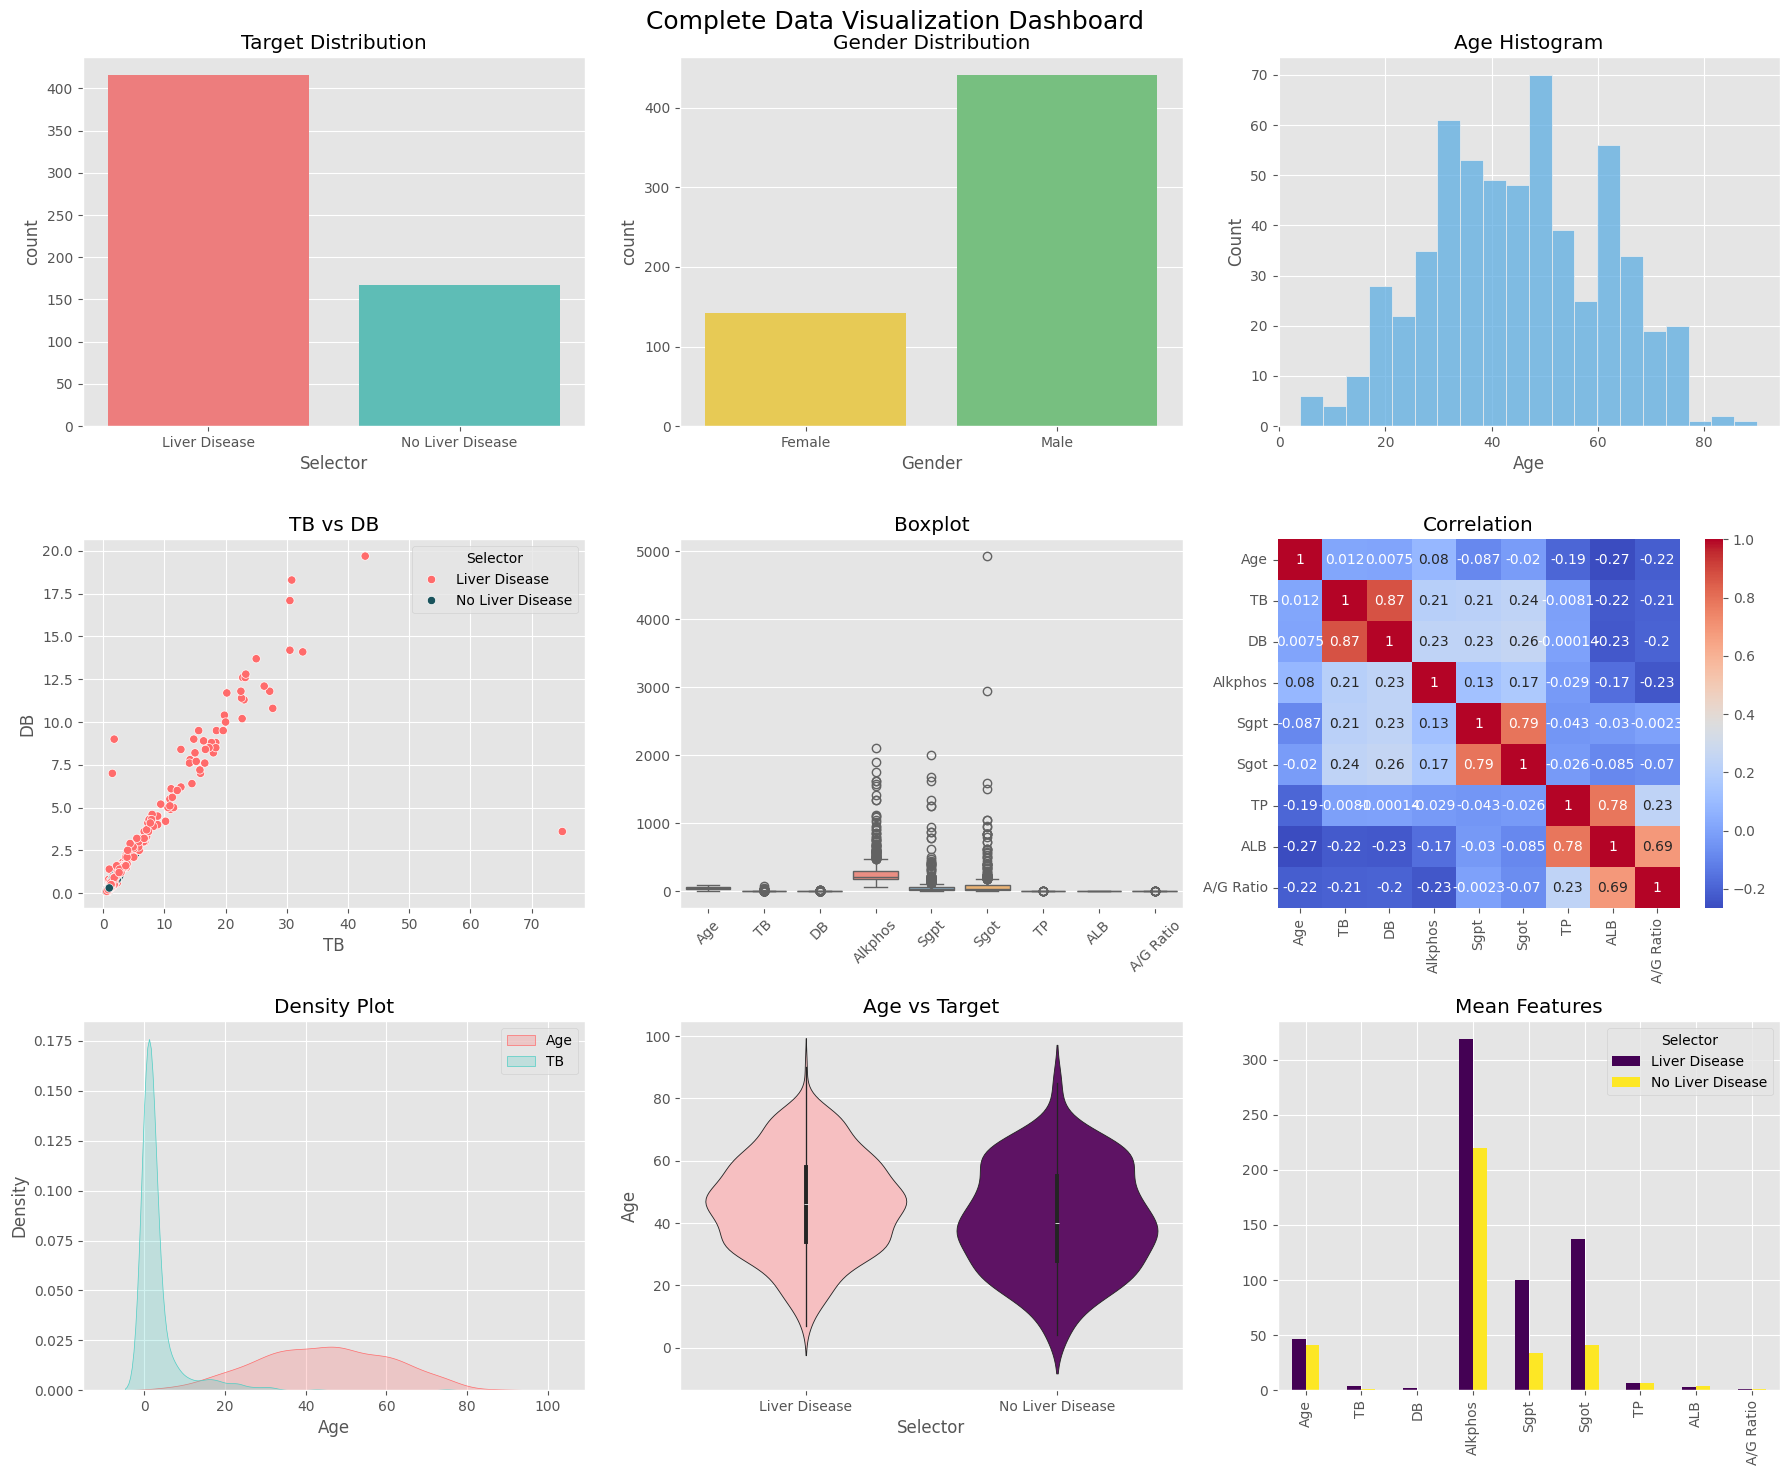

In [13]:
# ==============================
# STYLE
# ==============================
plt.style.use('ggplot')
sns.set_palette("Set2")

# Columns
numeric_cols = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

# ==============================
# CREATE SUBPLOTS
# ==============================
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Complete Data Visualization Dashboard", fontsize=18)

# ==============================
# 1. Target Distribution
# ==============================
sns.countplot(x='Selector', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[0,0])
axes[0,0].set_title("Target Distribution")

# ==============================
# 2. Gender Distribution
# ==============================
sns.countplot(x='Gender', data=df, palette=['#FFD93D', '#6BCB77'], ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

# ==============================
# 3. Age Distribution
# ==============================
sns.histplot(df['Age'], bins=20, color='#5DADE2', ax=axes[0,2])
axes[0,2].set_title("Age Histogram")

# ==============================
# 4. TB vs DB Scatter
# ==============================
sns.scatterplot(x='TB', y='DB', hue='Selector', data=df,
                palette=['#FF6B6B', '#1A535C'], ax=axes[1,0])
axes[1,0].set_title("TB vs DB")

# ==============================
# 5. Boxplot (Outliers)
# ==============================
sns.boxplot(data=df[numeric_cols], palette='Set3', ax=axes[1,1])
axes[1,1].set_title("Boxplot")
axes[1,1].tick_params(axis='x', rotation=45)

# ==============================
# 6. Correlation Heatmap
# ==============================
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title("Correlation")

# ==============================
# 7. KDE Plot
# ==============================
sns.kdeplot(df['Age'], fill=True, color='#FF6B6B', label='Age', ax=axes[2,0])
sns.kdeplot(df['TB'], fill=True, color='#4ECDC4', label='TB', ax=axes[2,0])
axes[2,0].legend()
axes[2,0].set_title("Density Plot")

# ==============================
# 8. Violin Plot
# ==============================
sns.violinplot(x='Selector', y='Age', data=df,
               palette=['#FFB6B9', '#6A0572'], ax=axes[2,1])
axes[2,1].set_title("Age vs Target")

# ==============================
# 9. Mean Feature Comparison
# ==============================
df.groupby('Selector')[numeric_cols].mean().T.plot(
    kind='bar',
    colormap='viridis',
    ax=axes[2,2]
)
axes[2,2].set_title("Mean Features")

# ==============================
# FINAL LAYOUT
# ==============================
plt.tight_layout()
plt.show()

## Feature engineering

Target Mapping: {'Liver Disease': np.int64(0), 'No Liver Disease': np.int64(1)}

Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.90      0.81        83
           1       0.43      0.18      0.25        34

    accuracy                           0.69       117
   macro avg       0.58      0.54      0.53       117
weighted avg       0.64      0.69      0.64       117


Random Forest
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        83
           1       0.36      0.26      0.31        34

    accuracy                           0.65       117
   macro avg       0.54      0.54      0.54       117
weighted avg       0.62      0.65      0.63       117


SVM
              precision    recall  f1-score   support

           0       0.70      0.95      0.81        83
           1       0.00      0.00      0.00        34

    accuracy                           0.68       117
   macr

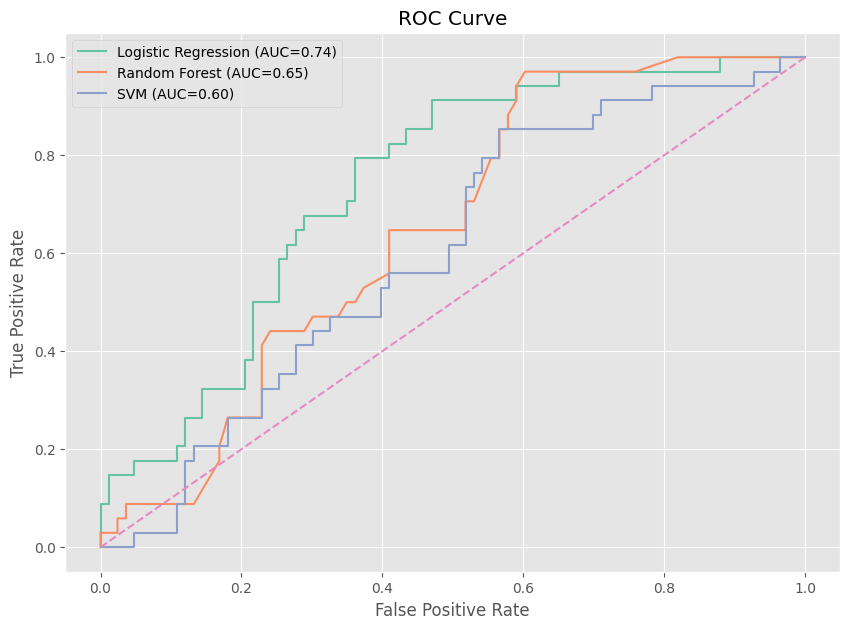


Final Comparison:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.692308   0.428571  0.176471  0.250000  0.737775
Random Forest        0.649573   0.360000  0.264706  0.305085  0.647945
SVM                  0.675214   0.000000  0.000000  0.000000  0.600992


In [14]:
# ==============================
# IMPORT LIBRARIES
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, classification_report
)

# ==============================
# CLEAN DATA
# ==============================
df = df.dropna()

# ==============================
# ENCODE TARGET (IMPORTANT FIX)
# ==============================
le = LabelEncoder()
df['Selector'] = le.fit_transform(df['Selector'])

# Now:
# e.g. 'Liver Disease' → 1, 'No Liver Disease' → 0

print("Target Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ==============================
# SPLIT FEATURES & TARGET
# ==============================
X = df.drop("Selector", axis=1)
y = df["Selector"]

# ==============================
# COLUMN TYPES
# ==============================
numeric_cols = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']
categorical_cols = ['Gender']

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# PREPROCESSING
# ==============================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])

# ==============================
# MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True)
}

# ==============================
# TRAIN + EVALUATE
# ==============================
results = {}

plt.figure(figsize=(10,7))

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics (NOW WORKS)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = [acc, prec, rec, f1, auc]

    print(f"\n{name}")
    print("="*40)
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# ==============================
# ROC CURVE
# ==============================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==============================
# FINAL RESULTS
# ==============================
results_df = pd.DataFrame(results).T
results_df.columns = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

print("\nFinal Comparison:")
print(results_df.sort_values(by="ROC AUC", ascending=False))